In [1]:
import pandas as pd, numpy as np, re, matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import word_tokenize, download
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction import text
import nltk

# Embeddings & topics
from sentence_transformers import SentenceTransformer
import umap
import hdbscan
from bertopic import BERTopic
from utils.data import load_data

# NLTK data
download('punkt', quiet=True)
download('stopwords', quiet=True)
download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)
try:
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt_tab', quiet=True)


STOP_WORDS = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

/Users/hunain/d/coding-projects/biodiversity-taxonomy-thesis/env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df, df_sample = load_data(sample_n=50000)


Loading dataset from local file...
Dataset shape: (359435, 72)
 Count Summary : {'row_count': 359435, 'web_of_science_record_count': np.int64(359435), 'web_of_science_record_distinct_count': 358933, 'duplicated_row_count': np.int64(502)}
Dropped 502 duplicated rows. Remaining rows: 358933
Dropped 16449 rows without Abstract. Remaining rows: 342484
Sampling 50000 rows from the dataset of length 342484.
 51 Columns with null values:
Cited References            342484
Meeting Abstract            342484
Book Group Authors          342461
Book Series Subtitle        342445
Group Authors               342178
Book Author Full Names      342068
Book Authors                342068
Conference Host             341191
Highly Cited Status         340300
Hot Paper Status            340300
Supplement                  340024
Conference Sponsor          339945
Part Number                 339633
Book DOI                    339045
Book Series Title           338975
Book Editors                337976
ISBN 

In [ ]:
def preprocess(text: str) -> str:
    text = text.lower() if isinstance(text, str) else ''
    tokens = [lemmatizer.lemmatize(tok) for tok in word_tokenize(text)
              if tok.isalpha() and tok not in STOP_WORDS and len(tok) > 2]
    return ' '.join(tokens)

df['text'] = (df['Article Title'].fillna('') + ' ' + df['Abstract'].fillna('')).apply(preprocess)
df = df[df['text'].str.strip().astype(bool)]
print('Clean corpus size:', len(df))


In [ ]:
bins = [(1985, 1994), (1995, 2004), (2005, 2014), (2015, 2025)]
labels = [f'{b[0]}–{b[1]}' for b in bins]

def decade_label(year):
    for (start, end), lab in zip(bins, labels):
        if start <= year <= end:
            return lab
    return 'Other'

df['Decade'] = df['Publication Year'].apply(decade_label)
df = df[df['Decade'] != 'Other']
df['Decade'].value_counts().sort_index()


Decade
1985–1994      6467
1995–2004     25771
2005–2014     85625
2015–2025    222761
Name: count, dtype: int64

## Keyword Mining - TF‑IDF

Generally, doesn't help inform

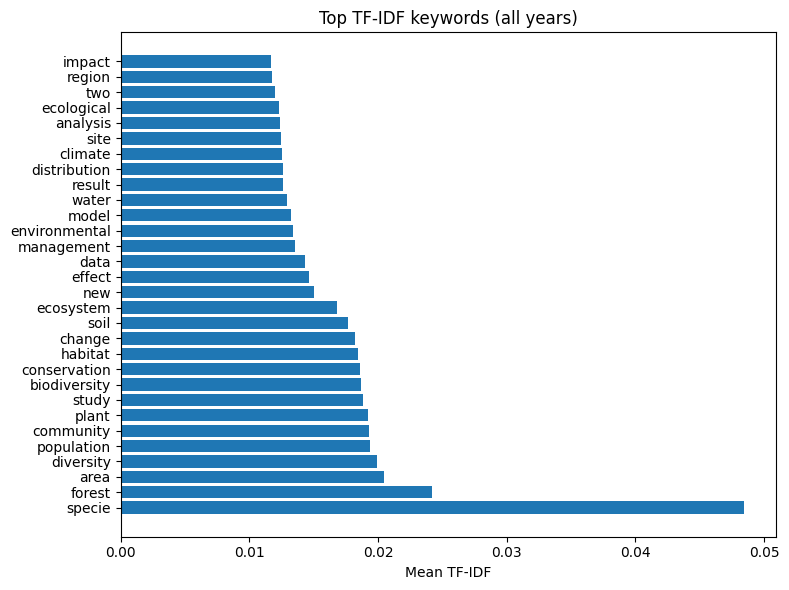

In [ ]:
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2), min_df=5)
X = vectorizer.fit_transform(df['text'])
tfidf_means = np.asarray(X.mean(axis=0)).ravel()
terms = np.array(vectorizer.get_feature_names_out())

top_n = 30
top_idx = tfidf_means.argsort()[::-1][:top_n]

plt.figure(figsize=(8,6))
plt.barh(range(top_n)[::-1], tfidf_means[top_idx][::-1])
plt.yticks(range(top_n)[::-1], terms[top_idx][::-1])
plt.title('Top TF‑IDF keywords (all years)')
plt.xlabel('Mean TF‑IDF')
plt.tight_layout()
plt.show()


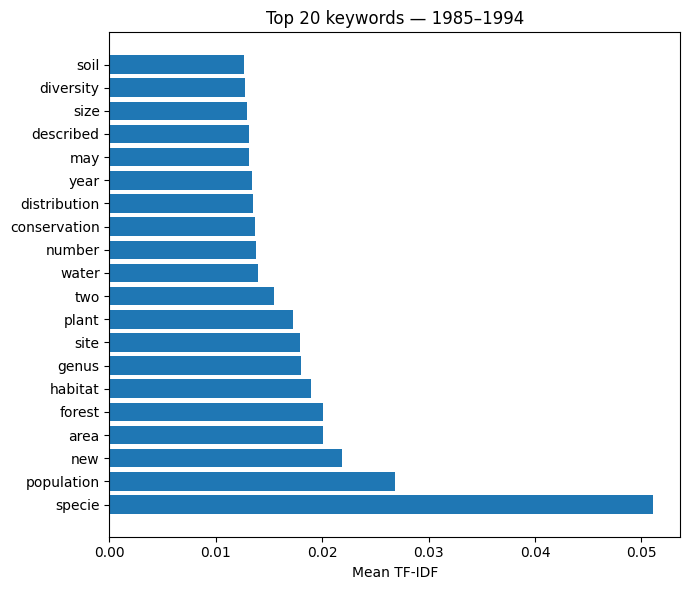

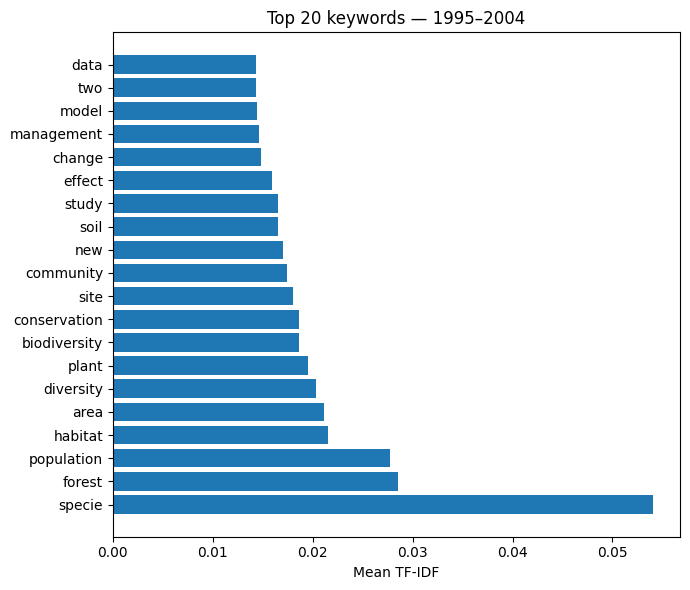

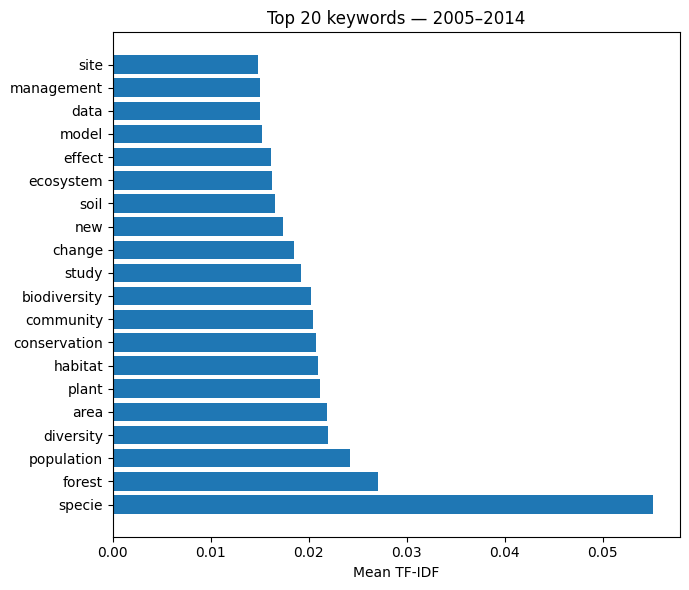

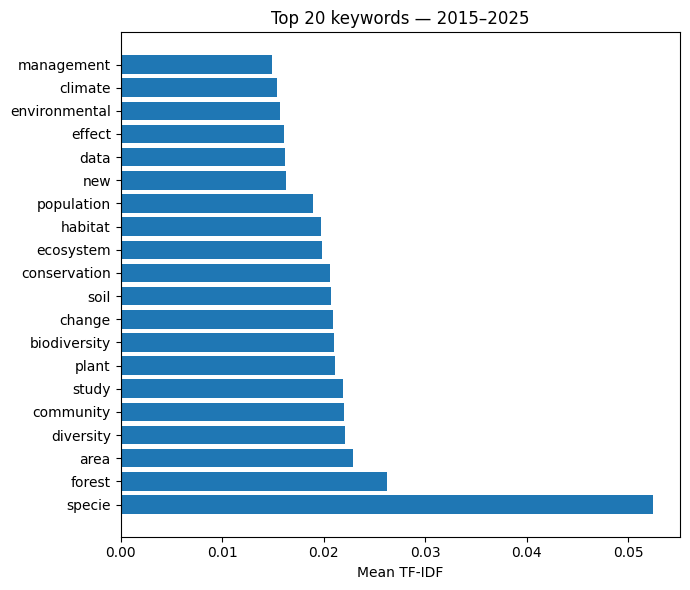

In [ ]:
# Per‑decade bar plots
n_per_decade = 20
for decade in labels:
    sub = df[df['Decade'] == decade]
    if sub.empty:
        continue
    vec = TfidfVectorizer(max_features=3000, ngram_range=(1,2), min_df=3)
    Xm = vec.fit_transform(sub['text'])
    means = np.asarray(Xm.mean(axis=0)).ravel()
    tms = np.array(vec.get_feature_names_out())
    idx = means.argsort()[::-1][:n_per_decade]

    plt.figure(figsize=(7,6))
    plt.barh(range(n_per_decade)[::-1], means[idx][::-1])
    plt.yticks(range(n_per_decade)[::-1], tms[idx][::-1])
    plt.title(f'Top {n_per_decade} keywords — {decade}')
    plt.xlabel('Mean TF‑IDF')
    plt.tight_layout()
    plt.show()


## Topic Discovery w/ BERTopic + SciBERT

In [ ]:
embed_model = SentenceTransformer('allenai/scibert_scivocab_uncased')
# embed_model = SentenceTransformer('allenai/specter2_base')


No sentence-transformers model found with name allenai/scibert_scivocab_uncased. Creating a new one with mean pooling.


In [ ]:
embeddings = embed_model.encode(df['text'].tolist(), show_progress_bar=True, batch_size=64)

topic_model = BERTopic(embedding_model=embed_model,
                       n_gram_range=(1,3),
                       min_topic_size=25,
                       calculate_probabilities=True,
                       verbose=True)

topics, probs = topic_model.fit_transform(df['text'], embeddings)

Batches:   1%|          | 27/5323 [02:29<18:22:59, 12.50s/it]

In [ ]:
# Interactive - topics (UMAP 2‑D)
topic_model.visualize_topics()


In [ ]:
topic_model.visualize_barchart(top_n_topics=20)


### Topics over time

In [ ]:
fig = topic_model.visualize_topics_over_time(df['text'], df['Year'])
fig
